# Quoridor AI — POC Training v3.1 (5×5)

**Group 501** | Colman College | DL Final Project

AlphaZero-inspired agent for Quoridor trained via self-play.

### Fixes in v3.1
* Increased dirichlet alpha from 0.3 to 1.2 to increase exploration

**Before running:**
1. Runtime → Change runtime type → **T4 GPU**
2. Run cells in order
3. If Colab disconnects, re-run from **Section 1** — `resume=True` picks up automatically

---
## 1. Environment Setup
Run once per Colab session.

In [1]:
import os
import sys

REPO_DIR = "./dl-quoridor"
BRANCH = "dev"

# 1. Clone the repository to get the 'src' folder
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/ReefKenig/dl-quoridor.git {REPO_DIR}

# 2. Move into the downloaded project folder
os.chdir(REPO_DIR)

# 3. Checkout your specific multiprocessing branch
!git fetch --all
!git checkout {BRANCH}
!git pull

# 4. Install dependencies to the active Jupyter kernel (using %pip instead of !pip)
%pip install -r requirements.txt

# 5. Ensure Python knows where to find the 'src' module
sys.path.append(os.getcwd())
print("Setup complete!")

Fetching origin
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 10 (delta 5), reused 10 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 1.43 KiB | 1.43 MiB/s, done.
From https://github.com/ReefKenig/dl-quoridor
   d145f1c..ad60071  dev        -> origin/dev
Already on 'dev'
Your branch is behind 'origin/dev' by 2 commits, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Updating d145f1c..ad60071
Fast-forward
 src/mcts/mcts.py               | 2 +-
 src/mcts/parallel_self_play.py | 2 +-
 2 files changed, 2 insertions(+), 2 deletions(-)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.2/532.2 MB 66.0 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 69.0 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 71.6 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
# 0 — Timestamp & duration utilities (run first)
!pip install humanize -q

import time
from datetime import datetime
import humanize

_cell_timers = {}

def ts(label=""):
    """Print a timestamp and start a timer for this label."""
    now = datetime.now()
    _cell_timers[label] = time.monotonic()
    tag = f"[{label}] " if label else ""
    print(f"⏱ {tag}Started at {now.strftime('%Y-%m-%d %H:%M:%S')}")

def te(label=""):
    """Print elapsed duration since ts() was called with the same label."""
    now = datetime.now()
    elapsed = time.monotonic() - _cell_timers.get(label, time.monotonic())
    tag = f"[{label}] " if label else ""
    duration = humanize.precisedelta(elapsed, minimum_unit="seconds", format="%0.0f")
    print(f"✅ {tag}Finished at {now.strftime('%Y-%m-%d %H:%M:%S')} — took {duration}")

print("Timestamp utils loaded (ts/te)")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Timestamp utils loaded (ts/te)


In [3]:
import sys
import subprocess

print(f"Installing PyTorch to: {sys.executable}\n")

# Force install torch directly to this kernel, ignoring cache to prevent disk-space crashes
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "torch", "numpy", "--no-cache-dir"],
    capture_output=True,
    text=True
)

print("--- INSTALLATION OUTPUT ---")
print(result.stdout)

if result.stderr:
    print("--- ERRORS / WARNINGS ---")
    print(result.stderr)
else:
    print("\n✅ Installation completed with no errors.")

Installing PyTorch to: /usr/bin/python3

--- INSTALLATION OUTPUT ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/532.2 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.8/532.2 MB 7.9 MB/s eta 0:01:08
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/532.2 MB 38.7 MB/s eta 0:00:14
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/532.2 MB 54.3 MB/s eta 0:00:10
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/532.2 MB 60.5 MB/s eta 0:00:09
   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/532.2 MB 64.6 MB/s eta 0:00:08
   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/532.2 MB 67.1 MB/s eta 0:00:07
   ━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/532.2 MB 68.4 MB/s eta 0:00:07
   ━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/532.2 MB 69.7 MB/s eta 0:00:07
   ━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/532.2 MB 70.8 MB/s eta 0:00:06
   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/532.2 MB 71.5 MB/s eta 0:00:06
   ━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/532.2 MB 

In [4]:
# 1.1 — Verify GPU
import torch

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be slow.")
    print("Go to Runtime → Change runtime type → T4 GPU")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 21.6 GB


In [5]:
# ── Anti-disconnect for Colab ──
# This JavaScript pings the Colab runtime to prevent idle timeout
# import IPython
# IPython.display.display(IPython.display.Javascript('''
# function KeepAlive() {
#     console.log("Keeping alive " + new Date().toLocaleTimeString());
#     document.querySelector("colab-toolbar-button#connect")?.click();
# }
# setInterval(KeepAlive, 60000);
# '''))
# print("Anti-disconnect activated (pings every 60s)")


In [6]:
# 1.2 — Mount Google Drive (checkpoints & logs persist here)
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
DRIVE_ROOT = "./v3_1"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"
LOG_DIR = f"{DRIVE_ROOT}/logs"

!mkdir -p "{CHECKPOINT_DIR}" "{LOG_DIR}"
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Logs:        {LOG_DIR}")

Checkpoints: ./v3_1/checkpoints
Logs:        ./v3_1/logs


---
## 2. Validation
Confirm all components work before training.

In [7]:
ts("Smoke test")

# 2.1 — Smoke test: full pipeline (env → tensor → model → MCTS → self-play)
from src.env.quoridor_env import QuoridorEnv
from src.model.network import QuoridorModel
from src.mcts.mcts import MCTS, MCTSConfig
from src.mcts.self_play import play_one_game

env = QuoridorEnv(is_poc=True)
env.max_walls_per_player = 3  # v2: reduced walls
model = QuoridorModel(
    board_size=5,
    action_space_size=44,
    in_channels=11,
    num_channels=16,
    num_res_blocks=2
)

def nn_evaluate(state):
    tensor = env.state_to_tensor(state)
    return model.predict(tensor)

mcts = MCTS(config=MCTSConfig(num_simulations=50), evaluate_fn=nn_evaluate)
samples, winner = play_one_game(env, mcts, max_moves=100)

original_count = len(samples) // 2  # half are augmented mirrors
print(f"Game: {original_count} moves, winner=P{winner}")
print(f"Total samples (with augmentation): {len(samples)} ({len(samples)/original_count:.0f}x)")
print(f"Tensor shape: {samples[0].state.shape}")
print(f"Policy shape: {samples[0].policy_target.shape}")

# Verify discounted values are NOT flat
values = [s.value_target for s in samples[:original_count]]
unique_vals = len(set(round(v, 4) for v in values))
print(f"Unique value targets: {unique_vals} (should be > 2)")

assert samples[0].state.shape == (5, 5, 11)
assert samples[0].policy_target.shape == (44,)
assert unique_vals > 2, "Value targets should be discounted, not flat!"
print("\n✓ Smoke test passed — pipeline + augmentation + discounted values working.")

te("Smoke test")

⏱ [Smoke test] Started at 2026-06-07 20:56:48
Game: 54 moves, winner=P1
Total samples (with augmentation): 108 (2x)
Tensor shape: (5, 5, 11)
Policy shape: (44,)
Unique value targets: 54 (should be > 2)

✓ Smoke test passed — pipeline + augmentation + discounted values working.
✅ [Smoke test] Finished at 2026-06-07 20:56:52 — took 4 seconds


In [8]:
# 2.2 — MCTS (random rollouts) vs random agent on real env
from src.mcts.evaluator import evaluate_against_random, mcts_agent

env = QuoridorEnv(is_poc=True)
env.max_walls_per_player = 3
mcts_random = MCTS(config=MCTSConfig(num_simulations=200))
agent = mcts_agent(mcts_random, temperature=0.1)

result = evaluate_against_random(env, agent, num_games=20)
print(result.summary())
print(f"\nMCTS wins {result.agent_a_win_rate:.0%} vs random (expected >60%)")

Games: 20 | A wins: 18 (90.0%) | B wins: 2 (10.0%) | Draws: 0 | Avg moves: 19.5 | Avg time: 1.41s

MCTS wins 90% vs random (expected >60%)


---
## 3. Training

In [9]:
ts("Training")

# 3 — Full POC training v2 (15 iterations)
# Re-run this cell after Colab disconnects — resume=True picks up from last checkpoint
#
# Fixes applied in this run:
#   1. Discounted value targets (gamma=0.97) — positions near game end get stronger signal
#   2. Data augmentation via left-right mirror — doubles effective training data
#   3. Reduced walls to 3/player — less wall saturation, faster offensive learning
#   4. 100 training epochs — better buffer utilisation per iteration
#   5. Exploration bonus: temp=1.0 for first 20 moves, 0.3 after — diverse openings

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    force=True,
)

from src.env.quoridor_env import QuoridorEnv
from src.model.network import QuoridorModel
from src.mcts.self_play import training_loop, TrainingConfig

env = QuoridorEnv(is_poc=True)
env.max_walls_per_player = 3  # reduced from 5 — 37.5% wall saturation vs 62.5%

model = QuoridorModel(
    board_size=5,
    action_space_size=44,
    in_channels=11,
    num_channels=64,
    num_res_blocks=4,
    lr=0.001
)

config = TrainingConfig(
    num_iterations=40,          # Increased (more steps of self-improvement)
    games_per_iteration=200,    # Increased (more diverse data per step)
    mcts_simulations=150,       # Decreased (faster games, perfectly fine for 5x5)
    batch_size=256,             # Kept the same
    training_epochs=8,          # Drastically decreased (prevents overfitting)
    eval_games=20,
    eval_random_games=20,
    win_threshold=0.55,
    replay_buffer_size=30000,   # Adjusted to match the new data scale
    self_play_checkpoint_freq=20,
    max_game_moves=60,          # Decreased (5x5 games rarely need 80 moves)
)

training_loop(
    env=env,
    model=model,
    config=config,
    checkpoint_dir=CHECKPOINT_DIR,
    log_dir=LOG_DIR,
    use_wandb=False,
    resume=True,
)

te("Training")

2026-06-07 20:57:20,545 [src.model.network] INFO: QuoridorModel: 306571 params, device=cuda, board=5x5, actions=44
2026-06-07 20:57:20,546 [src.utils.checkpoint] INFO: No checkpoint found in v3_1/checkpoints
2026-06-07 20:57:20,555 [src.mcts.self_play] INFO: ==================================================
2026-06-07 20:57:20,556 [src.mcts.self_play] INFO: Iteration 1/40
2026-06-07 20:57:20,557 [src.mcts.self_play] INFO:   Generating 200 self-play games...


⏱ [Training] Started at 2026-06-07 20:57:20


2026-06-07 20:58:57,646 [src.mcts.self_play] INFO:     Games: 20/200
2026-06-07 20:58:57,656 [src.model.network] INFO: Model saved to v3_1/checkpoints/iter_0000/model.pt
2026-06-07 20:58:57,664 [src.utils.checkpoint] INFO: Checkpoint saved: iter=0, buffer=1048, path=v3_1/checkpoints/iter_0000
2026-06-07 20:58:57,665 [src.mcts.self_play] INFO:     Mid-iteration checkpoint saved (20/200 games)
2026-06-07 21:00:58,248 [src.mcts.self_play] INFO:     Games: 40/200
2026-06-07 21:00:58,256 [src.model.network] INFO: Model saved to v3_1/checkpoints/iter_0000/model.pt
2026-06-07 21:00:58,274 [src.utils.checkpoint] INFO: Checkpoint saved: iter=0, buffer=2332, path=v3_1/checkpoints/iter_0000
2026-06-07 21:00:58,275 [src.mcts.self_play] INFO:     Mid-iteration checkpoint saved (40/200 games)
2026-06-07 21:02:46,741 [src.mcts.self_play] INFO:     Games: 60/200
2026-06-07 21:02:46,759 [src.model.network] INFO: Model saved to v3_1/checkpoints/iter_0000/model.pt
2026-06-07 21:02:46,783 [src.utils.check

✅ [Training] Finished at 2026-06-08 05:20:28 — took 8 hours, 23 minutes and 8 seconds


---
## 4. Monitor & Analyze Results

2026-06-08 05:20:28,737 [matplotlib.font_manager] INFO: generated new fontManager


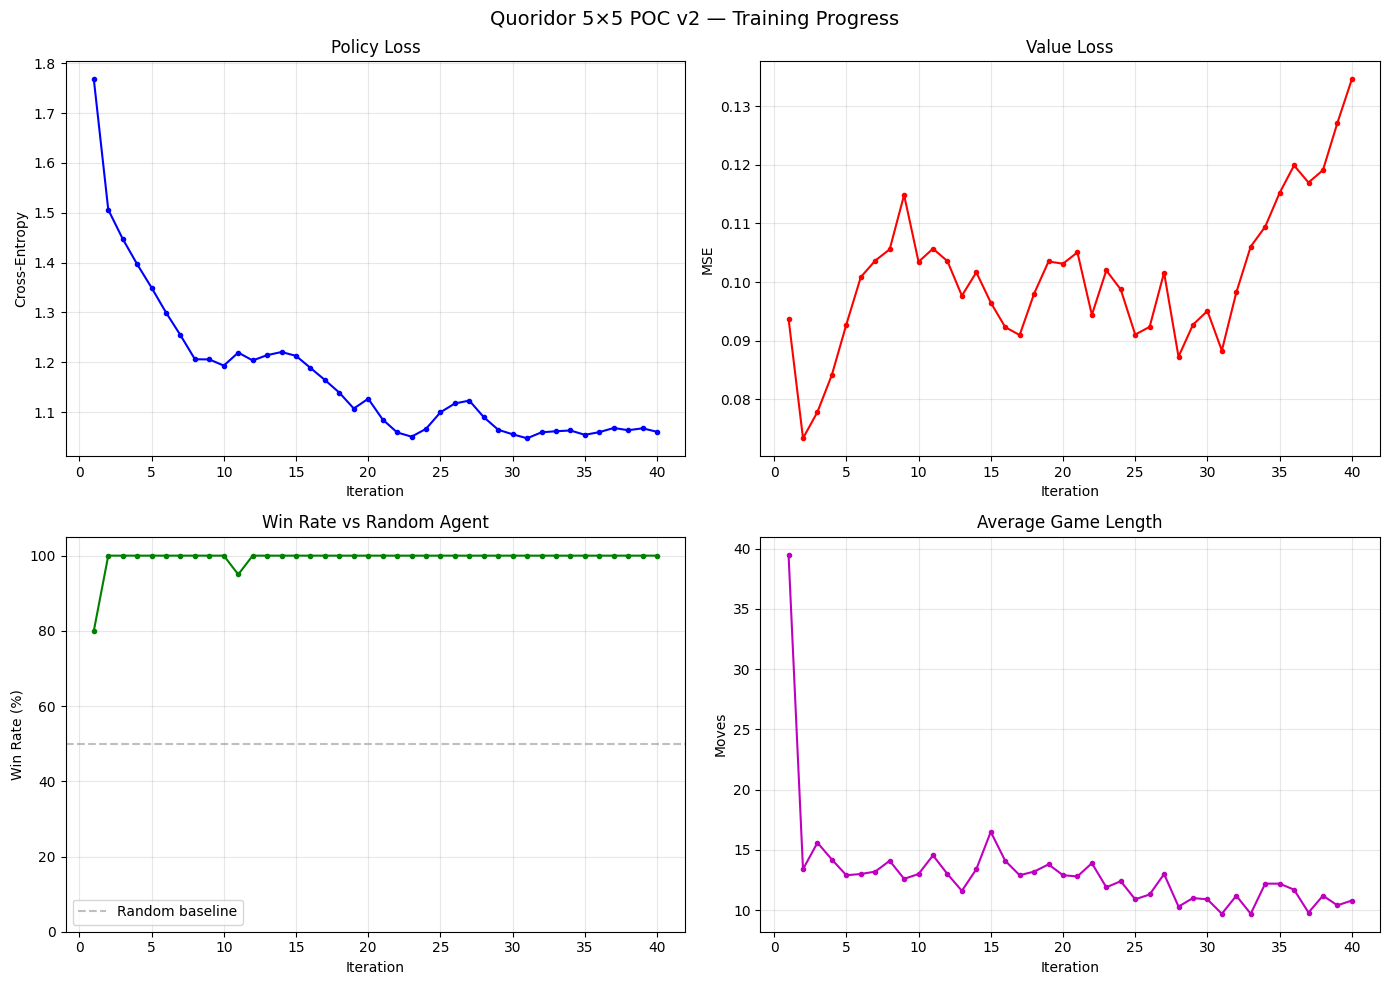


Latest iteration: 40
Policy loss: 1.0605
Value loss:  0.1346
Win rate:    100.0%


In [10]:
# 4.1 — Training curves
import json
import matplotlib.pyplot as plt

log_path = f"{LOG_DIR}/metrics_full.json"

try:
    with open(log_path) as f:
        metrics = json.load(f)
except FileNotFoundError:
    print("No metrics yet — run training first.")
    metrics = []

if metrics:
    iters = [m['iteration'] for m in metrics]
    loss_p = [m['loss_policy'] for m in metrics]
    loss_v = [m['loss_value'] for m in metrics]
    wr = [m['win_rate_vs_random'] for m in metrics]
    avg_len = [m['avg_game_length'] for m in metrics]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Quoridor 5×5 POC v2 — Training Progress', fontsize=14)

    axes[0, 0].plot(iters, loss_p, 'b-o', markersize=3)
    axes[0, 0].set_title('Policy Loss')
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Cross-Entropy')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(iters, loss_v, 'r-o', markersize=3)
    axes[0, 1].set_title('Value Loss')
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('MSE')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(iters, [w * 100 for w in wr], 'g-o', markersize=3)
    axes[1, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
    axes[1, 0].set_title('Win Rate vs Random Agent')
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Win Rate (%)')
    axes[1, 0].set_ylim(0, 105)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(iters, avg_len, 'm-o', markersize=3)
    axes[1, 1].set_title('Average Game Length')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Moves')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{LOG_DIR}/training_curves.png", dpi=150)
    plt.show()

    print(f"\nLatest iteration: {iters[-1]}")
    print(f"Policy loss: {loss_p[-1]:.4f}")
    print(f"Value loss:  {loss_v[-1]:.4f}")
    print(f"Win rate:    {wr[-1]:.1%}")

In [11]:
# 4.2 — Metrics table
if metrics:
    print(f"{'Iter':>4} | {'Loss_P':>8} | {'Loss_V':>8} | {'WR_Random':>10} | {'Avg_Len':>8} | {'Best':>5}")
    print("-" * 60)
    for m in metrics:
        print(
            f"{m['iteration']:4d} | "
            f"{m['loss_policy']:8.4f} | "
            f"{m['loss_value']:8.4f} | "
            f"{m['win_rate_vs_random']:9.1%} | "
            f"{m['avg_game_length']:8.1f} | "
            f"{'*' if m.get('model_accepted') else ''}"
        )

Iter |   Loss_P |   Loss_V |  WR_Random |  Avg_Len |  Best
------------------------------------------------------------
   1 |   1.7676 |   0.0937 |     80.0% |     39.5 | *
   2 |   1.5061 |   0.0734 |    100.0% |     13.4 | *
   3 |   1.4475 |   0.0779 |    100.0% |     15.6 | *
   4 |   1.3967 |   0.0842 |    100.0% |     14.2 | *
   5 |   1.3496 |   0.0928 |    100.0% |     12.9 | *
   6 |   1.2997 |   0.1008 |    100.0% |     13.0 | 
   7 |   1.2543 |   0.1037 |    100.0% |     13.2 | 
   8 |   1.2060 |   0.1056 |    100.0% |     14.1 | *
   9 |   1.2057 |   0.1148 |    100.0% |     12.6 | *
  10 |   1.1932 |   0.1034 |    100.0% |     13.0 | *
  11 |   1.2194 |   0.1057 |     95.0% |     14.6 | *
  12 |   1.2036 |   0.1036 |    100.0% |     13.0 | *
  13 |   1.2143 |   0.0977 |    100.0% |     11.6 | *
  14 |   1.2206 |   0.1017 |    100.0% |     13.4 | *
  15 |   1.2128 |   0.0965 |    100.0% |     16.5 | *
  16 |   1.1887 |   0.0923 |    100.0% |     14.1 | *
  17 |   1.1644 | 

---
## 5. Evaluate Best Model

In [12]:
# 5.1 — Load best model and evaluate thoroughly
from src.env.quoridor_env import QuoridorEnv
from src.model.network import QuoridorModel
from src.mcts.mcts import MCTS, MCTSConfig
from src.mcts.evaluator import evaluate_against_random, mcts_agent
import os

env = QuoridorEnv(is_poc=True)
env.max_walls_per_player = 3
best_model = QuoridorModel(
    board_size=5,
    action_space_size=44,
    in_channels=11
)

best_path = f"{CHECKPOINT_DIR}/best/model.pt"
if os.path.exists(best_path):
    best_model.load(best_path)
    print(f"Loaded best model from {best_path}")
else:
    print("No best model found — run training first.")

def best_nn_evaluate(state):
    tensor = env.state_to_tensor(state)
    return best_model.predict(tensor)

# Evaluate at different MCTS simulation counts
for sims in [100, 200, 400]:
    mcts = MCTS(
        config=MCTSConfig(num_simulations=sims),
        evaluate_fn=best_nn_evaluate,
    )
    agent = mcts_agent(mcts, temperature=0.1)
    result = evaluate_against_random(env, agent, num_games=50)
    print(f"  {sims:>4} sims: {result.summary()}")

2026-06-08 05:20:29,516 [src.model.network] INFO: QuoridorModel: 306571 params, device=cuda, board=5x5, actions=44
2026-06-08 05:20:29,538 [src.model.network] INFO: Model loaded from ./v3_1/checkpoints/best/model.pt


Loaded best model from ./v3_1/checkpoints/best/model.pt


2026-06-08 05:20:35,212 [src.mcts.evaluator] INFO:   [10/50] A: 10 | B: 0 | Draw: 0
2026-06-08 05:20:41,634 [src.mcts.evaluator] INFO:   [20/50] A: 20 | B: 0 | Draw: 0
2026-06-08 05:20:46,542 [src.mcts.evaluator] INFO:   [30/50] A: 30 | B: 0 | Draw: 0
2026-06-08 05:20:52,225 [src.mcts.evaluator] INFO:   [40/50] A: 40 | B: 0 | Draw: 0
2026-06-08 05:20:58,547 [src.mcts.evaluator] INFO:   [50/50] A: 50 | B: 0 | Draw: 0
2026-06-08 05:20:58,549 [src.mcts.evaluator] INFO: Eval complete: Games: 50 | A wins: 50 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 10.2 | Avg time: 0.58s


   100 sims: Games: 50 | A wins: 50 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 10.2 | Avg time: 0.58s


2026-06-08 05:21:09,696 [src.mcts.evaluator] INFO:   [10/50] A: 10 | B: 0 | Draw: 0
2026-06-08 05:21:20,817 [src.mcts.evaluator] INFO:   [20/50] A: 20 | B: 0 | Draw: 0
2026-06-08 05:21:31,901 [src.mcts.evaluator] INFO:   [30/50] A: 30 | B: 0 | Draw: 0
2026-06-08 05:21:41,541 [src.mcts.evaluator] INFO:   [40/50] A: 40 | B: 0 | Draw: 0
2026-06-08 05:21:54,501 [src.mcts.evaluator] INFO:   [50/50] A: 50 | B: 0 | Draw: 0
2026-06-08 05:21:54,502 [src.mcts.evaluator] INFO: Eval complete: Games: 50 | A wins: 50 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 10.6 | Avg time: 1.12s


   200 sims: Games: 50 | A wins: 50 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 10.6 | Avg time: 1.12s


2026-06-08 05:22:13,798 [src.mcts.evaluator] INFO:   [10/50] A: 10 | B: 0 | Draw: 0
2026-06-08 05:22:33,141 [src.mcts.evaluator] INFO:   [20/50] A: 20 | B: 0 | Draw: 0
2026-06-08 05:22:52,648 [src.mcts.evaluator] INFO:   [30/50] A: 30 | B: 0 | Draw: 0
2026-06-08 05:23:10,701 [src.mcts.evaluator] INFO:   [40/50] A: 40 | B: 0 | Draw: 0
2026-06-08 05:23:30,396 [src.mcts.evaluator] INFO:   [50/50] A: 50 | B: 0 | Draw: 0
2026-06-08 05:23:30,397 [src.mcts.evaluator] INFO: Eval complete: Games: 50 | A wins: 50 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 9.8 | Avg time: 1.92s


   400 sims: Games: 50 | A wins: 50 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 9.8 | Avg time: 1.92s


In [13]:
# 5.2 — Compare: trained model vs untrained model
from src.mcts.evaluator import evaluate

untrained_model = QuoridorModel(
    board_size=5,
    action_space_size=44,
    in_channels=11
)

def untrained_evaluate(state):
    tensor = env.state_to_tensor(state)
    return untrained_model.predict(tensor)

mcts_trained = MCTS(
    config=MCTSConfig(num_simulations=200),
    evaluate_fn=best_nn_evaluate,
)
mcts_untrained = MCTS(
    config=MCTSConfig(num_simulations=200),
    evaluate_fn=untrained_evaluate,
)

trained_agent = mcts_agent(mcts_trained, temperature=0.1)
untrained_agent = mcts_agent(mcts_untrained, temperature=0.1)

result = evaluate(env, agent_a=trained_agent, agent_b=untrained_agent, num_games=40)
print(f"Trained vs Untrained: {result.summary()}")

2026-06-08 05:23:30,408 [src.model.network] INFO: QuoridorModel: 306571 params, device=cuda, board=5x5, actions=44
2026-06-08 05:23:56,693 [src.mcts.evaluator] INFO:   [10/40] A: 10 | B: 0 | Draw: 0
2026-06-08 05:24:20,383 [src.mcts.evaluator] INFO:   [20/40] A: 20 | B: 0 | Draw: 0
2026-06-08 05:24:51,525 [src.mcts.evaluator] INFO:   [30/40] A: 30 | B: 0 | Draw: 0
2026-06-08 05:25:19,104 [src.mcts.evaluator] INFO:   [40/40] A: 40 | B: 0 | Draw: 0
2026-06-08 05:25:19,104 [src.mcts.evaluator] INFO: Eval complete: Games: 40 | A wins: 40 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 11.3 | Avg time: 2.72s


Trained vs Untrained: Games: 40 | A wins: 40 (100.0%) | B wins: 0 (0.0%) | Draws: 0 | Avg moves: 11.3 | Avg time: 2.72s
